In [1]:
import os

os.environ["MUJOCO_GL"] = "egl"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

In [2]:
import json
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from orbax import checkpoint as ocp
from scipy import stats

from track_mjx.agent import checkpointing
from track_mjx.agent.ff_ppo import ppo_networks as ff_ppo_networks
from track_mjx.agent.observation_utils import (
    get_obs_sizes,
    init_dict_normalizer,
)
from track_mjx.agent.checkpointing import _replace_zero_sized_arrays

from vnl_playground import naccdmax_patch
from vnl_playground import tasks
from vnl_playground.tasks.wrappers import PriorHighLevelWrapper
from vnl_playground.tasks.rodent.vision_jax import JaxVisionRenderer

[naccdmax_patch] Patched warp make_data/put_data: naccdmax defaults to naconmax


In [3]:
BASE_DIR = Path("/home/talmolab/Desktop/SalkResearch/vnl-playground")
CHECKPOINT_BASE = BASE_DIR / "highlvl_checkpoints"
CHECKPOINT_DIR = "260319_160751"

EPISODE_LENGTH = 1000
N_ENVS = 256
SEED = 42

EYE_YAW_RANGE = 0.698  # ±40° in radians

## Load Checkpoint

In [4]:
ckpt_path = CHECKPOINT_BASE / CHECKPOINT_DIR

# Load config
with open(ckpt_path / "config.json") as f:
    cfg_dict = json.load(f)
cfg = OmegaConf.create(cfg_dict)

# Load frozen decoder (SCAMPER prior)
from vnl_playground.tasks.prior_utils import (
    load_prior_checkpoint,
    make_decoder_inference_fn as make_scamper_decoder_fn,
    make_prior_inference_fn,
)

prior_path = cfg.transfer.prior_checkpoint_path
# Fix: on this machine the prior is nested under "default/"
prior_default = Path(prior_path) / "default"
if prior_default.exists():
    prior_path = str(prior_default)

prior_step = cfg.transfer.get("prior_checkpoint_step", None)
_enc_p, _pri_p, dec_p, dec_n, prior_cfg = load_prior_checkpoint(prior_path, prior_step)
latent_size = prior_cfg["network_config"]["intention_size"]
decoder_policy_fn = make_scamper_decoder_fn(dec_p, dec_n, prior_cfg)
prior_fn = make_prior_inference_fn(_pri_p, dec_n, prior_cfg)
mimic_cfg = OmegaConf.create(prior_cfg)

print(f"Latent size: {latent_size}")
print(f"Env: {cfg.env_config.env_name}")
print(f"Actuable eyes: {cfg.env_config.env_args.actuable_eyes}")
print(
    f"Eye yaw range: {cfg.env_config.env_args.eye_yaw_range} rad ({np.degrees(cfg.env_config.env_args.eye_yaw_range):.1f} deg)"
)

Latent size: 16
Env: RodentRunGapActuableEyes
Actuable eyes: True
Eye yaw range: 0.698 rad (40.0 deg)


In [5]:
# Create environment
env_args = (
    OmegaConf.to_container(cfg.env_config.get("env_args", {}), resolve=True) or {}
)
if hasattr(mimic_cfg, "env_config") and hasattr(mimic_cfg.env_config, "ctrl_dt"):
    env_args["ctrl_dt"] = float(mimic_cfg.env_config.ctrl_dt)

# Scale naconmax for N_ENVS worlds
eval_naconmax = cfg.train_setup.train_config.get("eval_naconmax", 2560)
num_eval_envs = cfg.train_setup.train_config.get("num_eval_envs", 128)
per_world_ncon = eval_naconmax / num_eval_envs
env_args["naconmax"] = max(256, int(per_world_ncon * N_ENVS))

raw_env = tasks.load(
    cfg.env_config.env_name,
    flatten_obs=False,
    config_overrides=env_args,
)

# Get n_eye_actuators from raw env
_unwrapped = raw_env
while hasattr(_unwrapped, "env"):
    _unwrapped = _unwrapped.env
n_eye_actuators = getattr(_unwrapped, "n_eye_actuators", 0)
eye_qpos_indices = getattr(_unwrapped, "_eye_qpos_indices", None)

print(f"n_eye_actuators: {n_eye_actuators}")
print(f"Eye qpos indices: {eye_qpos_indices}")
print(f"Raw env action_size: {raw_env.action_size}")

Warp 1.13.0.dev20260302 initialized:
   Git commit: 2675d53530597430af87c7425a1bbb40a2c5453a
   CUDA Toolkit 12.9, Driver 13.1
   Devices:
     "cpu"      : "CPU"
     "cuda:0"   : "NVIDIA GeForce RTX 5090" (31 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/talmolab/.cache/warp/1.13.0.dev20260302
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.
n_eye_actuators: 2
Eye qpos indices: [78 79]
Raw env action_size: 40


In [6]:
# Wrap with PriorHighLevelWrapper (with eye actuators)
highlvl_obs_key = cfg.transfer.get("highlvl_obs_key", "imitation_target")
decoder_obs_key = cfg.transfer.get("decoder_obs_key", "proprioception")

# Temporary wrapper to get obs_sizes
_tmp = PriorHighLevelWrapper(
    raw_env,
    prior_fn,
    decoder_policy_fn,
    latent_size,
    highlvl_obs_key=highlvl_obs_key,
    decoder_obs_key=decoder_obs_key,
    pass_vision=True,
    pass_task_obs=True,
    n_eye_actuators=n_eye_actuators,
)
_tmp_state = _tmp.reset(jax.random.PRNGKey(99))
obs_sizes = get_obs_sizes(_tmp_state.obs)
del _tmp, _tmp_state

print(f"Obs sizes: {obs_sizes}")
print(
    f"Policy action size: latent({latent_size}) + eyes({n_eye_actuators}) = {latent_size + n_eye_actuators}"
)

Module mujoco.mjx.warp.ffi 98d2031 load on device 'cuda:0' took 0.26 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.smooth 12773d5 load on device 'cuda:0' took 3.53 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.collision_driver 4d8b905 load on device 'cuda:0' took 0.23 ms  (cached)
Module _nxn_broadphase__locals__kernel_ea6098d7 ea6098d load on device 'cuda:0' took 0.23 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_ba2335e3 ba2335e load on device 'cuda:0' took 1.38 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_47e99e6d 47e99e6 load on device 'cuda:0' took 1.11 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_201d3c22 201d3c2 load on device 'cuda:0' took 0.93 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_4d39dd93 4d39dd9 load on device 'cuda:0' took 0.95 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_f0f83fea f0f83fe load on device 'cuda:0' took 1.09 ms  (cached)
Module _primitive_narrowphase__locals

In [7]:
# Build PPO network (action_size = latent_size + n_eye_actuators)
network_fn_name = cfg.network_config.get("arch_name", "shared_vision_task_obs")
mono_channels = 1 if cfg.env_config.get("grayscale", True) else 3
n_channels = 2 * mono_channels  # binocular
vision_shape = (
    cfg.env_config.get("vision_height", 32),
    cfg.env_config.get("vision_width", 32),
    n_channels,
)
policy_action_size = latent_size + n_eye_actuators

ppo_network, shared_module = (
    ff_ppo_networks.make_binocular_shared_vision_task_obs_highlvl_ppo_networks(
        obs_sizes=obs_sizes,
        action_size=policy_action_size,
        vision_shape=vision_shape,
        vision_latent_size=cfg.network_config.vision_latent_size,
        vision_feature_size=cfg.network_config.get("vision_feature_size", 32),
        decoder_hidden_layer_sizes=tuple(cfg.network_config.decoder_hidden_layer_sizes),
        value_hidden_layer_sizes=tuple(cfg.network_config.value_hidden_layer_sizes),
        vision_channels=tuple(cfg.network_config.vision_channels),
        fusion_hidden_layer_sizes=tuple(
            cfg.network_config.get("fusion_hidden_layer_sizes", [256])
        ),
        shared_weights=cfg.network_config.get("binocular_mode", "shared") == "shared",
    )
)

print(
    f"Network: {network_fn_name}, vision_shape={vision_shape}, action_size={policy_action_size}"
)

Network: binocular_shared_vision_task_obs, vision_shape=(32, 32, 2), action_size=18


In [8]:
# Restore checkpoint params
ckpt_mgr = ocp.CheckpointManager(
    str(ckpt_path),
    options=ocp.CheckpointManagerOptions(
        save_interval_steps=1,
        max_to_keep=200,
        step_prefix="PPONetwork",
        create=False,
    ),
)
latest_step = ckpt_mgr.latest_step()

key_policy, _ = jax.random.split(jax.random.PRNGKey(0))
init_policy_params = ppo_network.policy_network.init(key_policy)
dummy_obs = {
    "imitation_target": jnp.zeros((1, obs_sizes["imitation_target"])),
    "proprioception": jnp.zeros((1, obs_sizes["proprioception"])),
}
abstract_policy = _replace_zero_sized_arrays(
    (init_dict_normalizer(dummy_obs), init_policy_params)
)
normalizer_params, policy_params = ckpt_mgr.restore(
    latest_step,
    args=ocp.args.Composite(policy=ocp.args.StandardRestore(abstract_policy)),
)["policy"]
params_tuple = (normalizer_params, policy_params)

print(f"Restored checkpoint step {latest_step}")

Restored checkpoint step 132


In [9]:
# Set up binocular renderers and eval env
left_cam = cfg.env_config.get("left_camera_name", "eye_left_actuated-rodent")
right_cam = cfg.env_config.get("right_camera_name", "eye_right_actuated-rodent")
vw = cfg.env_config.get("vision_width", 32)
vh = cfg.env_config.get("vision_height", 32)
gs = cfg.env_config.get("grayscale", True)

left_renderer = JaxVisionRenderer(
    mj_model=raw_env.mj_model,
    mjx_model=raw_env.mjx_model,
    nworld=N_ENVS,
    width=vw,
    height=vh,
    grayscale=gs,
    camera_name=left_cam,
)
right_renderer = JaxVisionRenderer(
    mj_model=raw_env.mj_model,
    mjx_model=raw_env.mjx_model,
    nworld=N_ENVS,
    width=vw,
    height=vh,
    grayscale=gs,
    camera_name=right_cam,
)

eval_env = PriorHighLevelWrapper(
    raw_env,
    prior_fn,
    decoder_policy_fn,
    latent_size,
    highlvl_obs_key=highlvl_obs_key,
    decoder_obs_key=decoder_obs_key,
    pass_vision=True,
    pass_task_obs=True,
    n_eye_actuators=n_eye_actuators,
)

# Batched eval functions
vmapped_reset = jax.vmap(eval_env.reset)
vmapped_step = jax.vmap(eval_env.step)


def _inject_vision(obs, vision):
    if "vision" in obs:
        return {**obs, "vision": vision}
    if "state" in obs and "vision" in obs["state"]:
        return {**obs, "state": {**obs["state"], "vision": vision}}
    return obs


def eval_reset(rngs):
    states = vmapped_reset(rngs)
    left_img = left_renderer.render(states.data)
    right_img = right_renderer.render(states.data)
    vision = jnp.concatenate([left_img, right_img], axis=-1)
    return states.replace(obs=_inject_vision(states.obs, vision))


def eval_step(states, actions):
    states = vmapped_step(states, actions)
    left_img = left_renderer.render(states.data)
    right_img = right_renderer.render(states.data)
    vision = jnp.concatenate([left_img, right_img], axis=-1)
    return states.replace(obs=_inject_vision(states.obs, vision))


make_logging_policy = ff_ppo_networks.make_logging_inference_fn(ppo_network)
jit_inference_fn = jax.jit(make_logging_policy(deterministic=True))
jit_eval_reset = jax.jit(eval_reset)
jit_eval_step = jax.jit(eval_step)

import mujoco

torso_body_id = mujoco.mj_name2id(
    raw_env.mj_model, mujoco.mjtObj.mjOBJ_BODY, "torso-rodent"
)
qpos_start = raw_env._rodent_qpos_start

print("Eval pipeline ready.")

Module mujoco.mjx.third_party.mujoco_warp._src.render_util 9cda0d9 load on device 'cuda:0' took 0.38 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.io 4ae9eac load on device 'cuda:0' took 1.61 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.bvh 4527052 load on device 'cuda:0' took 0.46 ms  (cached)
Eval pipeline ready.


## Run Batched Rollout

In [10]:
# Helper: extract gap geometry from environment state
def extract_gap_info(raw_env, state):
    """Extract gap start/end positions from platform layout."""
    platform_body_ids = raw_env._platform_body_ids
    platform_half_length = raw_env._platform_half_length
    start_platform_body_id = raw_env._start_platform_body_id
    start_platform_half_length = raw_env._start_platform_half_length
    plat_centers = np.array(state.data.xpos[platform_body_ids, 0])
    plat_starts = plat_centers - platform_half_length
    plat_ends = plat_centers + platform_half_length
    start_end = (
        float(state.data.xpos[start_platform_body_id, 0]) + start_platform_half_length
    )
    all_trailing_edges = np.concatenate([[start_end], plat_ends])
    gap_starts = all_trailing_edges[:-1]
    gap_ends = plat_starts
    gap_lengths = gap_ends - gap_starts
    return gap_starts, gap_ends, gap_lengths


def compute_gap_proximity(rodent_x, gap_starts, gap_ends):
    """For each position, compute distance to nearest gap edge. 0 if inside a gap."""
    gap_proximity = np.zeros(len(rodent_x))
    for t, rx in enumerate(rodent_x):
        min_dist = float("inf")
        for gs, ge in zip(gap_starts, gap_ends):
            if gs <= rx <= ge:
                min_dist = 0.0
            else:
                d = min(abs(rx - gs), abs(rx - ge))
                min_dist = min(min_dist, d)
        gap_proximity[t] = min_dist
    return gap_proximity


def compute_signed_gap_distance(rodent_x, gap_starts, gap_ends):
    """Signed distance to nearest gap center. Negative = approaching, positive = past."""
    gap_centers = (gap_starts + gap_ends) / 2
    signed_dist = np.zeros(len(rodent_x))
    for t, rx in enumerate(rodent_x):
        dists = rx - gap_centers
        nearest_idx = np.argmin(np.abs(dists))
        signed_dist[t] = dists[nearest_idx]
    return signed_dist

In [11]:
# Run rollout
rngs = jax.random.split(jax.random.PRNGKey(SEED), N_ENVS)
states = jit_eval_reset(rngs)
act_rng = jax.random.PRNGKey(SEED + 1)

# Storage: (T, N_ENVS) for per-step data
all_rewards = []
all_dones = []
all_torso_x = []
all_torso_z = []
all_eye_left_yaw = []  # eye joint angles from qpos
all_eye_right_yaw = []
all_eye_left_ctrl = []  # policy eye control outputs
all_eye_right_ctrl = []

# Eye qpos indices (2 values: left yaw, right yaw)
eye_qpos_idx = jnp.array(eye_qpos_indices)

print(f"Running {N_ENVS} envs x {EPISODE_LENGTH} steps...")
for i in range(EPISODE_LENGTH):
    _, act_rng = jax.random.split(act_rng)
    actions, _ = jit_inference_fn(params_tuple, states.obs, act_rng)
    states = jit_eval_step(states, actions)

    all_rewards.append(states.reward)
    all_dones.append(states.done)
    all_torso_x.append(states.data.qpos[:, qpos_start - 7])
    all_torso_z.append(states.data.xpos[:, torso_body_id, 2])

    # Eye yaw angles from qpos (actual joint position)
    all_eye_left_yaw.append(states.data.qpos[:, eye_qpos_idx[0]])
    all_eye_right_yaw.append(states.data.qpos[:, eye_qpos_idx[1]])

    # Eye control actions (last 2 entries of the policy action)
    all_eye_left_ctrl.append(actions[:, -2])
    all_eye_right_ctrl.append(actions[:, -1])

    if (i + 1) % 200 == 0:
        mean_r = float(jnp.mean(jnp.stack(all_rewards)))
        print(f"  Step {i+1}/{EPISODE_LENGTH}, mean_reward={mean_r:.3f}")

print("Rollout complete.")

Module render__locals___render_megakernel_0a16a0a5 0a16a0a load on device 'cuda:0' took 0.63 ms  (cached)
Running 256 envs x 1000 steps...


E0325 09:41:31.123853 2626033 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.21 = f32[256,1024]{1,0} fusion(mul.93, constant.1063, constant.867), kind=kCustom, calls=gemm_fusion_dot_general.21_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"2","output_tiles":[{"sizes":["32","16"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":true,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0325 09:41:31.123881 2626033 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.21_computation.clone {
  parameter_0.5 = f32[256,1024]{1,0} parameter(0)
  parameter_1.5 = f32[1024]{0} parameter(1)
  add.37 = f32[256,1024]{1,0} broadcast(parameter_1.5), dimensions={1}
  add.38 = f32[256,1024]{1,0} add(parameter_0.5, add.37)
  parameter_2.4 = f32[1024,1024]{1,0} paramete

  Step 200/1000, mean_reward=0.699
  Step 400/1000, mean_reward=0.474
  Step 600/1000, mean_reward=0.340
  Step 800/1000, mean_reward=0.264
  Step 1000/1000, mean_reward=0.217
Rollout complete.


In [12]:
# Stack into arrays: (T, N_ENVS)
rewards = np.array(jnp.stack(all_rewards))
dones = np.array(jnp.stack(all_dones))
torso_x = np.array(jnp.stack(all_torso_x))
torso_z = np.array(jnp.stack(all_torso_z))
eye_left_yaw = np.array(jnp.stack(all_eye_left_yaw))
eye_right_yaw = np.array(jnp.stack(all_eye_right_yaw))
eye_left_ctrl = np.array(jnp.stack(all_eye_left_ctrl))
eye_right_ctrl = np.array(jnp.stack(all_eye_right_ctrl))

# Compute vergence: convergence = -(left_yaw - right_yaw)
# When both eyes turn inward (converge), left_yaw > 0 and right_yaw < 0
# So vergence = left_yaw - right_yaw > 0 means convergence
vergence = eye_left_yaw - eye_right_yaw

# Compute version (conjugate gaze direction): average of both eyes
version = (eye_left_yaw + eye_right_yaw) / 2

# Active mask: True for steps before terminal
cumulative_done = np.cumsum(dones, axis=0)
active_mask = cumulative_done <= 1

# Per-env summary
any_done = np.any(dones > 0.5, axis=0)
first_done_step = np.argmax(dones > 0.5, axis=0)
survival_steps = np.where(any_done, first_done_step + 1, EPISODE_LENGTH)
total_reward = np.sum(rewards * active_mask, axis=0)
max_x = np.max(torso_x * active_mask + (-1e6) * (~active_mask), axis=0)

print(f"Total reward: {np.mean(total_reward):.2f} +/- {np.std(total_reward):.2f}")
print(f"Survival: {np.mean(survival_steps):.0f} +/- {np.std(survival_steps):.0f} steps")
print(f"Max forward pos: {np.mean(max_x):.2f} +/- {np.std(max_x):.2f} m")
print(
    f"Eye left yaw range: [{np.min(eye_left_yaw):.3f}, {np.max(eye_left_yaw):.3f}] rad"
)
print(
    f"Eye right yaw range: [{np.min(eye_right_yaw):.3f}, {np.max(eye_right_yaw):.3f}] rad"
)

Total reward: 193.77 +/- 141.67
Survival: 270 +/- 181 steps
Max forward pos: 2.30 +/- 1.30 m
Eye left yaw range: [-0.696, 0.694] rad
Eye right yaw range: [-0.691, 0.646] rad


In [13]:
# Compute gap proximity for all environments
# We compute per-env gap info since gaps are randomized
gap_proximity_all = np.zeros_like(torso_x)  # (T, N_ENVS)
signed_gap_dist_all = np.zeros_like(torso_x)

for env_i in range(N_ENVS):
    env_state = jax.tree.map(lambda x: x[env_i], states)
    gs, ge, gl = extract_gap_info(raw_env, env_state)
    # Only use valid gaps (positive length)
    valid = gl > 0.005
    gs_valid, ge_valid = gs[valid], ge[valid]
    gap_proximity_all[:, env_i] = compute_gap_proximity(
        torso_x[:, env_i], gs_valid, ge_valid
    )
    signed_gap_dist_all[:, env_i] = compute_signed_gap_distance(
        torso_x[:, env_i], gs_valid, ge_valid
    )
    if env_i == 0:
        print(f"Env 0: {valid.sum()} valid gaps, lengths: {gl[valid][:5].round(3)}")

print(f"Gap proximity shape: {gap_proximity_all.shape}")

Env 0: 20 valid gaps, lengths: [0.118 0.072 0.127 0.077 0.196]
Gap proximity shape: (1000, 256)


## Eye Movement Time Series (Example Environments)

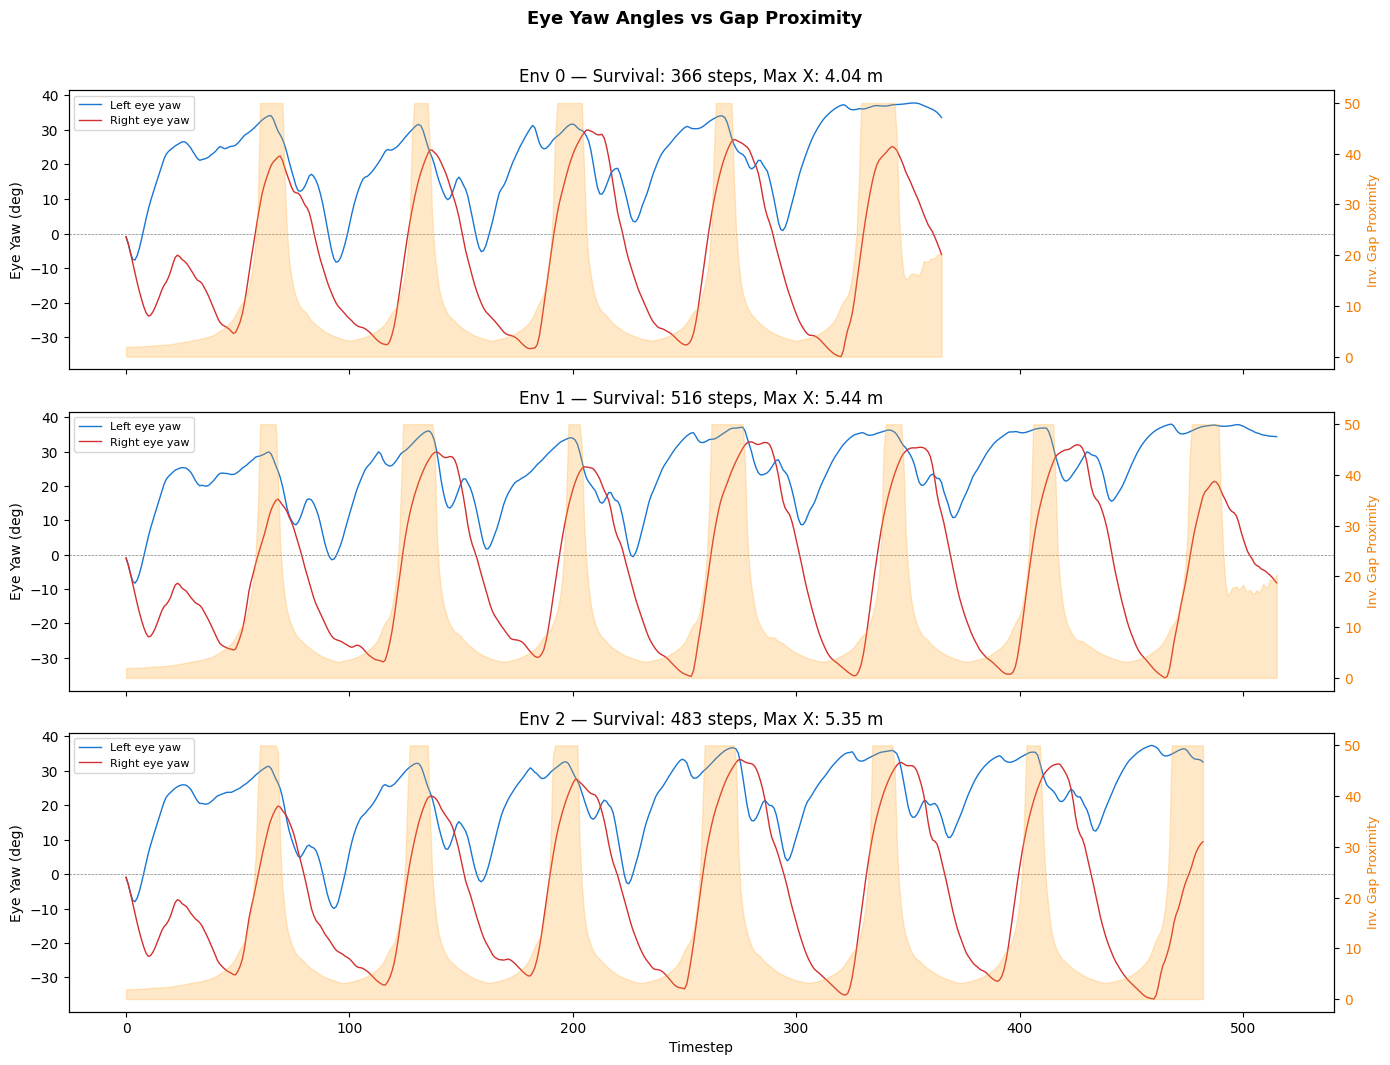

In [14]:
# Plot eye yaw angles and gap proximity for 3 example envs
example_envs = [0, 1, 2]
fig, axes = plt.subplots(
    len(example_envs), 1, figsize=(14, 3.5 * len(example_envs)), sharex=True
)

for ax_i, env_i in enumerate(example_envs):
    ax = axes[ax_i]
    T_alive = int(survival_steps[env_i])
    t = np.arange(T_alive)

    # Eye angles (convert to degrees for readability)
    ax.plot(
        t,
        np.degrees(eye_left_yaw[:T_alive, env_i]),
        color="#1976D2",
        lw=1,
        label="Left eye yaw",
    )
    ax.plot(
        t,
        np.degrees(eye_right_yaw[:T_alive, env_i]),
        color="#D32F2F",
        lw=1,
        label="Right eye yaw",
    )

    # Gap proximity as shaded background (inverted: darker = closer to gap)
    ax2 = ax.twinx()
    gap_prox = gap_proximity_all[:T_alive, env_i]
    inv_prox = 1.0 / (gap_prox + 0.02)
    ax2.fill_between(
        t, 0, inv_prox, color="#FFA726", alpha=0.25, label="1 / (gap dist + 0.02)"
    )
    ax2.set_ylabel("Inv. Gap Proximity", color="#F57C00", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="#F57C00")

    ax.set_ylabel("Eye Yaw (deg)")
    ax.set_title(
        f"Env {env_i} — Survival: {T_alive} steps, Max X: {max_x[env_i]:.2f} m"
    )
    ax.legend(loc="upper left", fontsize=8)
    ax.axhline(0, color="gray", ls="--", lw=0.5)

axes[-1].set_xlabel("Timestep")
fig.suptitle("Eye Yaw Angles vs Gap Proximity", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Vergence and Version vs Gap Proximity

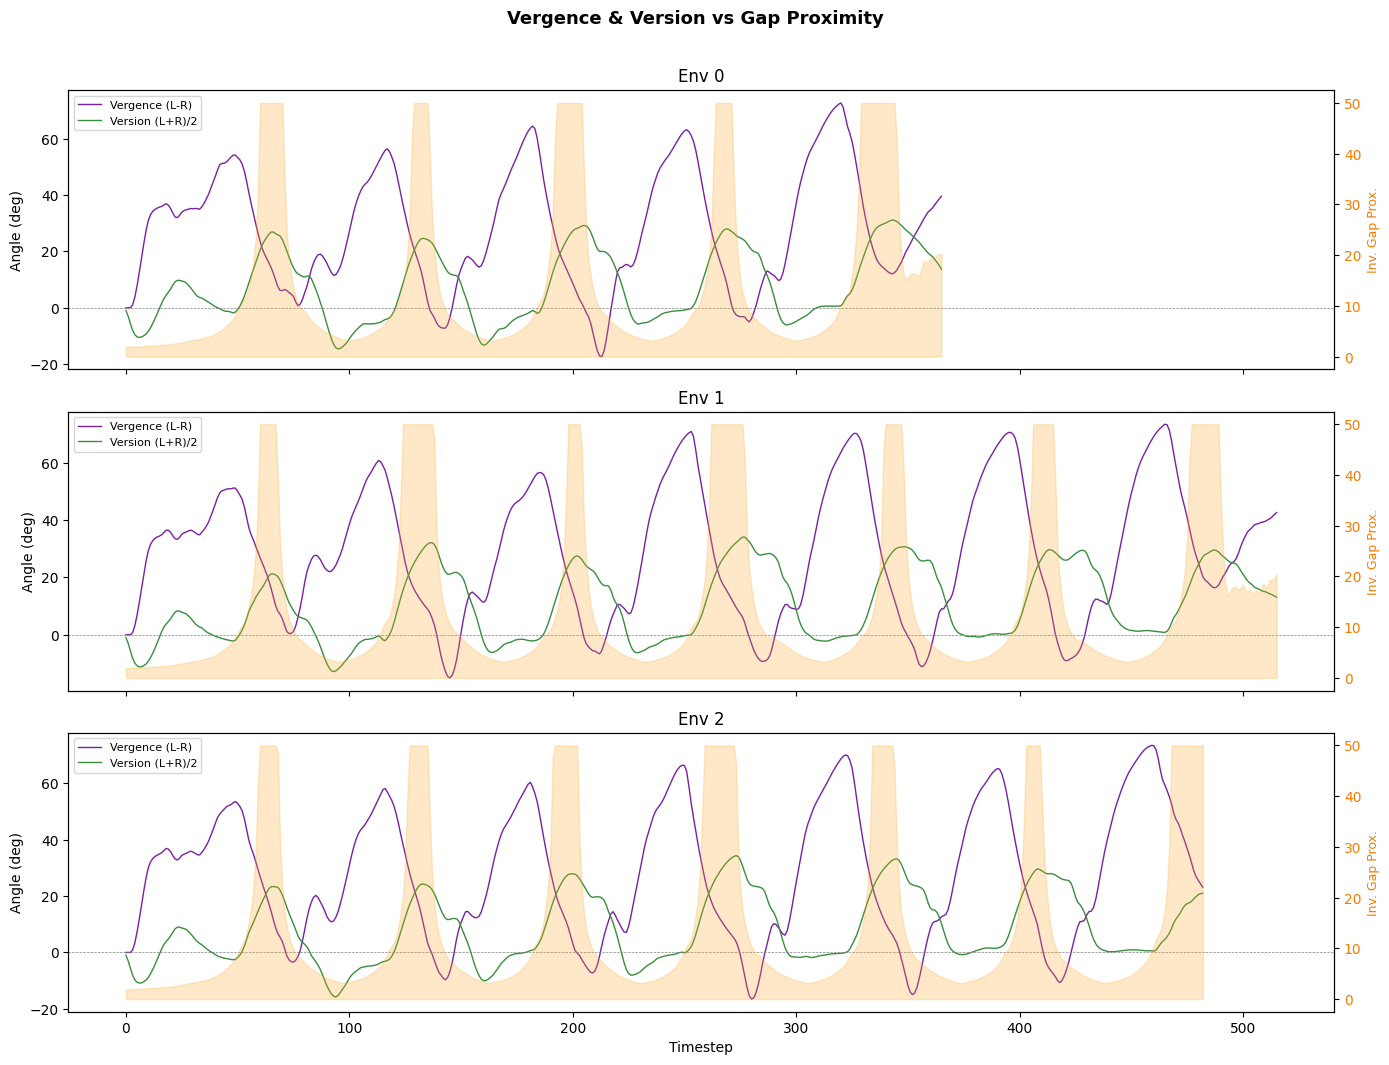

In [15]:
# Vergence and Version for example envs
fig, axes = plt.subplots(
    len(example_envs), 1, figsize=(14, 3.5 * len(example_envs)), sharex=True
)

for ax_i, env_i in enumerate(example_envs):
    ax = axes[ax_i]
    T_alive = int(survival_steps[env_i])
    t = np.arange(T_alive)

    ax.plot(
        t,
        np.degrees(vergence[:T_alive, env_i]),
        color="#7B1FA2",
        lw=1,
        label="Vergence (L-R)",
    )
    ax.plot(
        t,
        np.degrees(version[:T_alive, env_i]),
        color="#388E3C",
        lw=1,
        label="Version (L+R)/2",
    )

    ax2 = ax.twinx()
    gap_prox = gap_proximity_all[:T_alive, env_i]
    inv_prox = 1.0 / (gap_prox + 0.02)
    ax2.fill_between(t, 0, inv_prox, color="#FFA726", alpha=0.25)
    ax2.set_ylabel("Inv. Gap Prox.", color="#F57C00", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="#F57C00")

    ax.set_ylabel("Angle (deg)")
    ax.set_title(f"Env {env_i}")
    ax.legend(loc="upper left", fontsize=8)
    ax.axhline(0, color="gray", ls="--", lw=0.5)

axes[-1].set_xlabel("Timestep")
fig.suptitle(
    "Vergence & Version vs Gap Proximity", fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

## Eye Movements Binned by Gap Proximity (All Environments)

In [16]:
# Collect all active timesteps across all envs
flat_gap_prox = []
flat_eye_left = []
flat_eye_right = []
flat_vergence = []
flat_version = []
flat_eye_speed_left = []
flat_eye_speed_right = []

for env_i in range(N_ENVS):
    T_alive = int(survival_steps[env_i])
    if T_alive < 2:
        continue
    flat_gap_prox.append(gap_proximity_all[:T_alive, env_i])
    flat_eye_left.append(eye_left_yaw[:T_alive, env_i])
    flat_eye_right.append(eye_right_yaw[:T_alive, env_i])
    flat_vergence.append(vergence[:T_alive, env_i])
    flat_version.append(version[:T_alive, env_i])
    # Eye angular velocity (deg/step)
    dl = np.abs(np.diff(eye_left_yaw[:T_alive, env_i]))
    dr = np.abs(np.diff(eye_right_yaw[:T_alive, env_i]))
    flat_eye_speed_left.append(np.concatenate([[0], dl]))
    flat_eye_speed_right.append(np.concatenate([[0], dr]))

flat_gap_prox = np.concatenate(flat_gap_prox)
flat_eye_left = np.concatenate(flat_eye_left)
flat_eye_right = np.concatenate(flat_eye_right)
flat_vergence = np.concatenate(flat_vergence)
flat_version = np.concatenate(flat_version)
flat_eye_speed_left = np.concatenate(flat_eye_speed_left)
flat_eye_speed_right = np.concatenate(flat_eye_speed_right)
flat_eye_speed_mean = (flat_eye_speed_left + flat_eye_speed_right) / 2

print(f"Total active timesteps: {len(flat_gap_prox):,}")

Total active timesteps: 68,996


In [17]:
# Bin by gap proximity and compute statistics
bin_edges = np.array([0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 1.0])
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_labels = [
    f"{bin_edges[i]:.2f}-{bin_edges[i+1]:.2f}" for i in range(len(bin_edges) - 1)
]
bin_indices = np.digitize(flat_gap_prox, bin_edges) - 1

# Stats per bin
vergence_by_bin = {"mean": [], "std": [], "n": []}
version_by_bin = {"mean": [], "std": [], "n": []}
eye_speed_by_bin = {"mean": [], "std": [], "n": []}
abs_vergence_by_bin = {"mean": [], "std": [], "n": []}

for b in range(len(bin_edges) - 1):
    mask = bin_indices == b
    n = mask.sum()
    vergence_by_bin["n"].append(n)
    version_by_bin["n"].append(n)
    eye_speed_by_bin["n"].append(n)
    abs_vergence_by_bin["n"].append(n)
    if n > 0:
        vergence_by_bin["mean"].append(np.degrees(np.mean(flat_vergence[mask])))
        vergence_by_bin["std"].append(np.degrees(np.std(flat_vergence[mask])))
        version_by_bin["mean"].append(np.degrees(np.mean(flat_version[mask])))
        version_by_bin["std"].append(np.degrees(np.std(flat_version[mask])))
        eye_speed_by_bin["mean"].append(np.degrees(np.mean(flat_eye_speed_mean[mask])))
        eye_speed_by_bin["std"].append(np.degrees(np.std(flat_eye_speed_mean[mask])))
        abs_vergence_by_bin["mean"].append(
            np.degrees(np.mean(np.abs(flat_vergence[mask])))
        )
        abs_vergence_by_bin["std"].append(
            np.degrees(np.std(np.abs(flat_vergence[mask])))
        )
    else:
        for d in [
            vergence_by_bin,
            version_by_bin,
            eye_speed_by_bin,
            abs_vergence_by_bin,
        ]:
            d["mean"].append(np.nan)
            d["std"].append(np.nan)

for d in [vergence_by_bin, version_by_bin, eye_speed_by_bin, abs_vergence_by_bin]:
    for k in d:
        d[k] = np.array(d[k])

print("Samples per bin:", vergence_by_bin["n"])

Samples per bin: [ 9885  4339 12126 18630  5133 11459  7424     0]


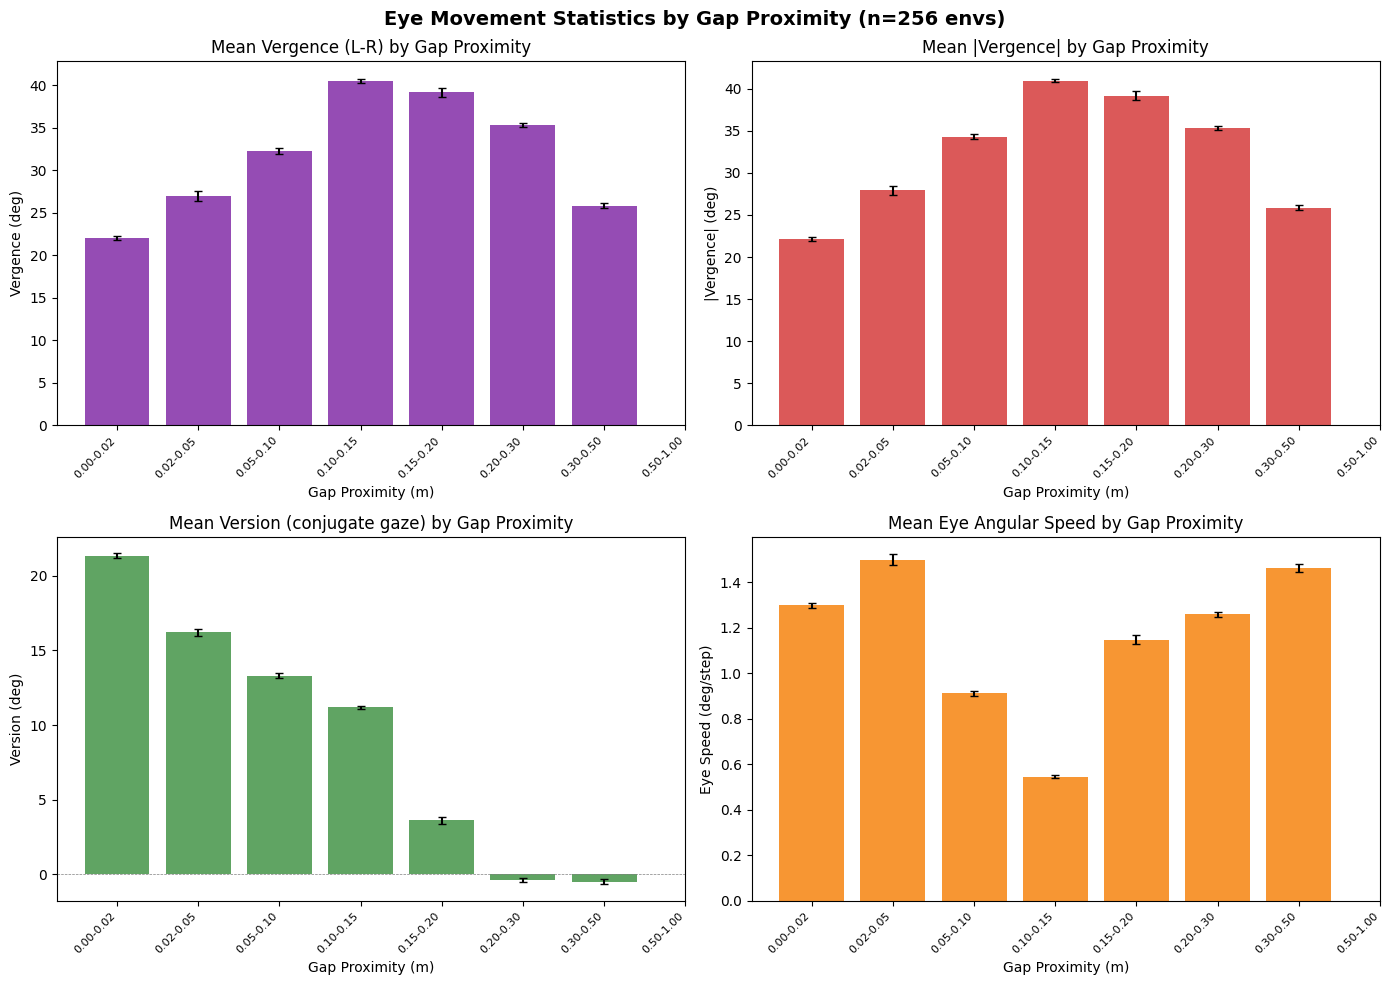

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x_pos = np.arange(len(bin_labels))
se_scale = 1.96  # 95% CI

# (a) Mean vergence by gap proximity bin
ax = axes[0, 0]
se = vergence_by_bin["std"] / np.sqrt(vergence_by_bin["n"])
ax.bar(
    x_pos,
    vergence_by_bin["mean"],
    color="#7B1FA2",
    alpha=0.8,
    yerr=se * se_scale,
    capsize=3,
)
ax.set_xticks(x_pos)
ax.set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Gap Proximity (m)")
ax.set_ylabel("Vergence (deg)")
ax.set_title("Mean Vergence (L-R) by Gap Proximity")
ax.axhline(0, color="gray", ls="--", lw=0.5)

# (b) |Vergence| by gap proximity
ax = axes[0, 1]
se = abs_vergence_by_bin["std"] / np.sqrt(abs_vergence_by_bin["n"])
ax.bar(
    x_pos,
    abs_vergence_by_bin["mean"],
    color="#D32F2F",
    alpha=0.8,
    yerr=se * se_scale,
    capsize=3,
)
ax.set_xticks(x_pos)
ax.set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Gap Proximity (m)")
ax.set_ylabel("|Vergence| (deg)")
ax.set_title("Mean |Vergence| by Gap Proximity")

# (c) Version by gap proximity
ax = axes[1, 0]
se = version_by_bin["std"] / np.sqrt(version_by_bin["n"])
ax.bar(
    x_pos,
    version_by_bin["mean"],
    color="#388E3C",
    alpha=0.8,
    yerr=se * se_scale,
    capsize=3,
)
ax.set_xticks(x_pos)
ax.set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Gap Proximity (m)")
ax.set_ylabel("Version (deg)")
ax.set_title("Mean Version (conjugate gaze) by Gap Proximity")
ax.axhline(0, color="gray", ls="--", lw=0.5)

# (d) Eye speed by gap proximity
ax = axes[1, 1]
se = eye_speed_by_bin["std"] / np.sqrt(eye_speed_by_bin["n"])
ax.bar(
    x_pos,
    eye_speed_by_bin["mean"],
    color="#F57C00",
    alpha=0.8,
    yerr=se * se_scale,
    capsize=3,
)
ax.set_xticks(x_pos)
ax.set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Gap Proximity (m)")
ax.set_ylabel("Eye Speed (deg/step)")
ax.set_title("Mean Eye Angular Speed by Gap Proximity")

fig.suptitle(
    f"Eye Movement Statistics by Gap Proximity (n={N_ENVS} envs)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## Gap-Triggered Eye Movement Averages\n\nAlign eye movements relative to gap crossings to see stereotyped patterns.

In [19]:
# Gap-triggered average: align eye movements to the moment the rodent reaches each gap edge
WINDOW_BEFORE = 100  # timesteps before gap edge
WINDOW_AFTER = 50  # timesteps after gap edge

aligned_left = []
aligned_right = []
aligned_vergence = []
aligned_version = []

for env_i in range(N_ENVS):
    T_alive = int(survival_steps[env_i])
    if T_alive < WINDOW_BEFORE + WINDOW_AFTER:
        continue
    env_state = jax.tree.map(lambda x: x[env_i], states)
    gs, ge, gl = extract_gap_info(raw_env, env_state)
    valid = gl > 0.005
    gs_valid = gs[valid]

    tx = torso_x[:T_alive, env_i]
    for gap_start in gs_valid:
        # Find the timestep where rodent crosses the gap leading edge
        cross_idx = np.where(tx >= gap_start)[0]
        if len(cross_idx) == 0:
            continue
        t_cross = cross_idx[0]
        t0 = t_cross - WINDOW_BEFORE
        t1 = t_cross + WINDOW_AFTER
        if t0 < 0 or t1 > T_alive:
            continue
        aligned_left.append(eye_left_yaw[t0:t1, env_i])
        aligned_right.append(eye_right_yaw[t0:t1, env_i])
        aligned_vergence.append(vergence[t0:t1, env_i])
        aligned_version.append(version[t0:t1, env_i])

aligned_left = np.array(aligned_left)
aligned_right = np.array(aligned_right)
aligned_vergence = np.array(aligned_vergence)
aligned_version = np.array(aligned_version)

print(f"Collected {len(aligned_left)} gap approach events")

Collected 268 gap approach events


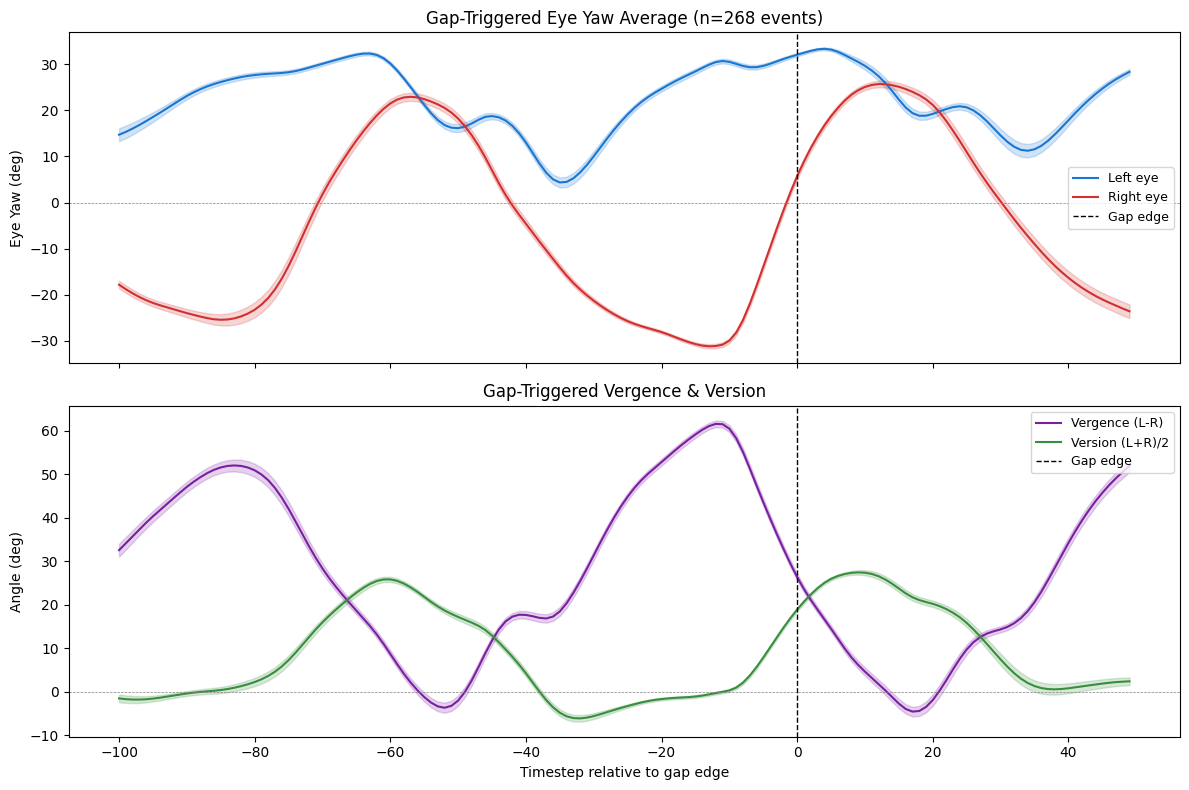

In [20]:
if len(aligned_left) > 0:
    t_rel = np.arange(-WINDOW_BEFORE, WINDOW_AFTER)
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # (a) Left and right eye yaw
    ax = axes[0]
    mean_l = np.degrees(np.mean(aligned_left, axis=0))
    se_l = np.degrees(np.std(aligned_left, axis=0) / np.sqrt(len(aligned_left)))
    mean_r = np.degrees(np.mean(aligned_right, axis=0))
    se_r = np.degrees(np.std(aligned_right, axis=0) / np.sqrt(len(aligned_right)))

    ax.plot(t_rel, mean_l, color="#1976D2", lw=1.5, label="Left eye")
    ax.fill_between(
        t_rel, mean_l - 1.96 * se_l, mean_l + 1.96 * se_l, color="#1976D2", alpha=0.2
    )
    ax.plot(t_rel, mean_r, color="#D32F2F", lw=1.5, label="Right eye")
    ax.fill_between(
        t_rel, mean_r - 1.96 * se_r, mean_r + 1.96 * se_r, color="#D32F2F", alpha=0.2
    )
    ax.axvline(0, color="black", ls="--", lw=1, label="Gap edge")
    ax.set_ylabel("Eye Yaw (deg)")
    ax.set_title(f"Gap-Triggered Eye Yaw Average (n={len(aligned_left)} events)")
    ax.legend(fontsize=9)
    ax.axhline(0, color="gray", ls="--", lw=0.5)

    # (b) Vergence and version
    ax = axes[1]
    mean_vg = np.degrees(np.mean(aligned_vergence, axis=0))
    se_vg = np.degrees(
        np.std(aligned_vergence, axis=0) / np.sqrt(len(aligned_vergence))
    )
    mean_vs = np.degrees(np.mean(aligned_version, axis=0))
    se_vs = np.degrees(np.std(aligned_version, axis=0) / np.sqrt(len(aligned_version)))

    ax.plot(t_rel, mean_vg, color="#7B1FA2", lw=1.5, label="Vergence (L-R)")
    ax.fill_between(
        t_rel,
        mean_vg - 1.96 * se_vg,
        mean_vg + 1.96 * se_vg,
        color="#7B1FA2",
        alpha=0.2,
    )
    ax.plot(t_rel, mean_vs, color="#388E3C", lw=1.5, label="Version (L+R)/2")
    ax.fill_between(
        t_rel,
        mean_vs - 1.96 * se_vs,
        mean_vs + 1.96 * se_vs,
        color="#388E3C",
        alpha=0.2,
    )
    ax.axvline(0, color="black", ls="--", lw=1, label="Gap edge")
    ax.set_ylabel("Angle (deg)")
    ax.set_xlabel("Timestep relative to gap edge")
    ax.set_title("Gap-Triggered Vergence & Version")
    ax.legend(fontsize=9)
    ax.axhline(0, color="gray", ls="--", lw=0.5)

    plt.tight_layout()
    plt.show()
else:
    print("No gap approach events collected.")

## Correlations and Distributions

In [21]:
# Correlation: eye metrics vs inverse gap proximity
inv_prox = 1.0 / (flat_gap_prox + 0.02)

metrics = {
    "Left eye yaw": flat_eye_left,
    "Right eye yaw": flat_eye_right,
    "Vergence (L-R)": flat_vergence,
    "Version (L+R)/2": flat_version,
    "|Vergence|": np.abs(flat_vergence),
    "Eye speed": flat_eye_speed_mean,
}

print("Pearson correlations with 1/(gap_proximity + 0.02):")
print("-" * 55)
corr_results = {}
for name, vals in metrics.items():
    r, p = stats.pearsonr(vals, inv_prox)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {name:20s}: r={r:+.4f}, p={p:.2e} {sig}")
    corr_results[name] = (r, p)

Pearson correlations with 1/(gap_proximity + 0.02):
-------------------------------------------------------
  Left eye yaw        : r=+0.3475, p=0.00e+00 ***
  Right eye yaw       : r=+0.5005, p=0.00e+00 ***
  Vergence (L-R)      : r=-0.2546, p=0.00e+00 ***
  Version (L+R)/2     : r=+0.5631, p=0.00e+00 ***
  |Vergence|          : r=-0.2742, p=0.00e+00 ***
  Eye speed           : r=+0.1179, p=3.44e-212 ***


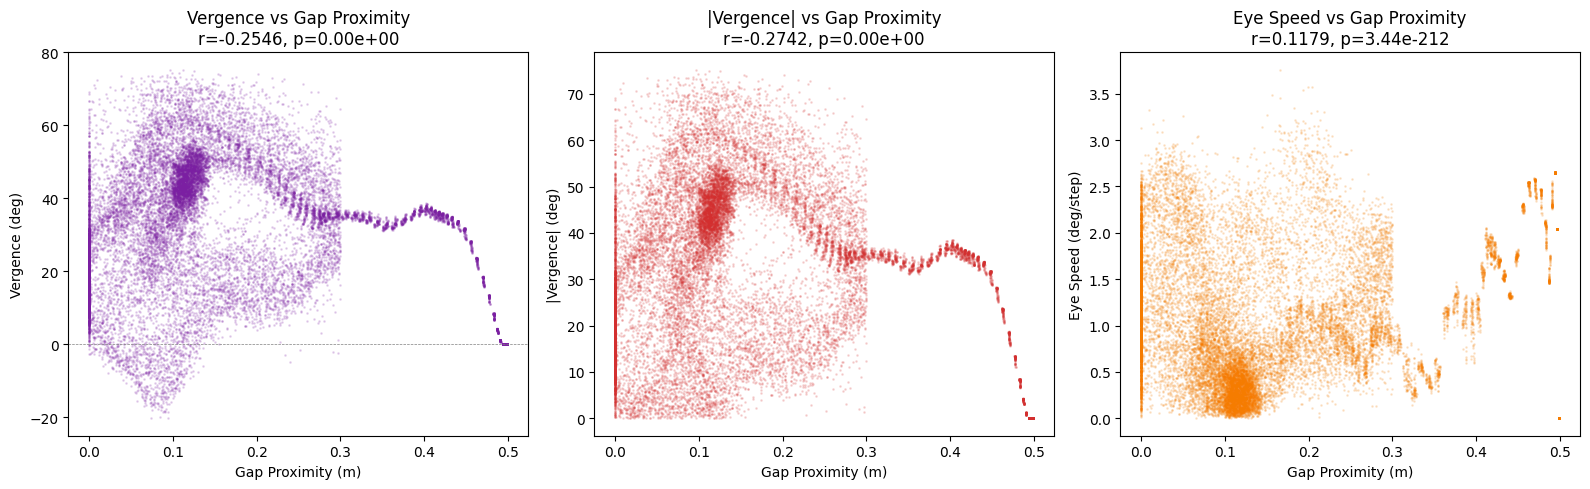

In [22]:
# Scatter/density: vergence and eye speed vs gap proximity
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Subsample for scatter (too many points otherwise)
n_total = len(flat_gap_prox)
subsample = np.random.default_rng(42).choice(
    n_total, min(20000, n_total), replace=False
)

ax = axes[0]
ax.scatter(
    flat_gap_prox[subsample],
    np.degrees(flat_vergence[subsample]),
    s=1,
    alpha=0.15,
    color="#7B1FA2",
    rasterized=True,
)
ax.set_xlabel("Gap Proximity (m)")
ax.set_ylabel("Vergence (deg)")
r, p = corr_results["Vergence (L-R)"]
ax.set_title(f"Vergence vs Gap Proximity\nr={r:.4f}, p={p:.2e}")
ax.axhline(0, color="gray", ls="--", lw=0.5)

ax = axes[1]
ax.scatter(
    flat_gap_prox[subsample],
    np.degrees(np.abs(flat_vergence[subsample])),
    s=1,
    alpha=0.15,
    color="#D32F2F",
    rasterized=True,
)
ax.set_xlabel("Gap Proximity (m)")
ax.set_ylabel("|Vergence| (deg)")
r, p = corr_results["|Vergence|"]
ax.set_title(f"|Vergence| vs Gap Proximity\nr={r:.4f}, p={p:.2e}")

ax = axes[2]
ax.scatter(
    flat_gap_prox[subsample],
    np.degrees(flat_eye_speed_mean[subsample]),
    s=1,
    alpha=0.15,
    color="#F57C00",
    rasterized=True,
)
ax.set_xlabel("Gap Proximity (m)")
ax.set_ylabel("Eye Speed (deg/step)")
r, p = corr_results["Eye speed"]
ax.set_title(f"Eye Speed vs Gap Proximity\nr={r:.4f}, p={p:.2e}")

plt.tight_layout()
plt.show()

## Eye Angle Distributions

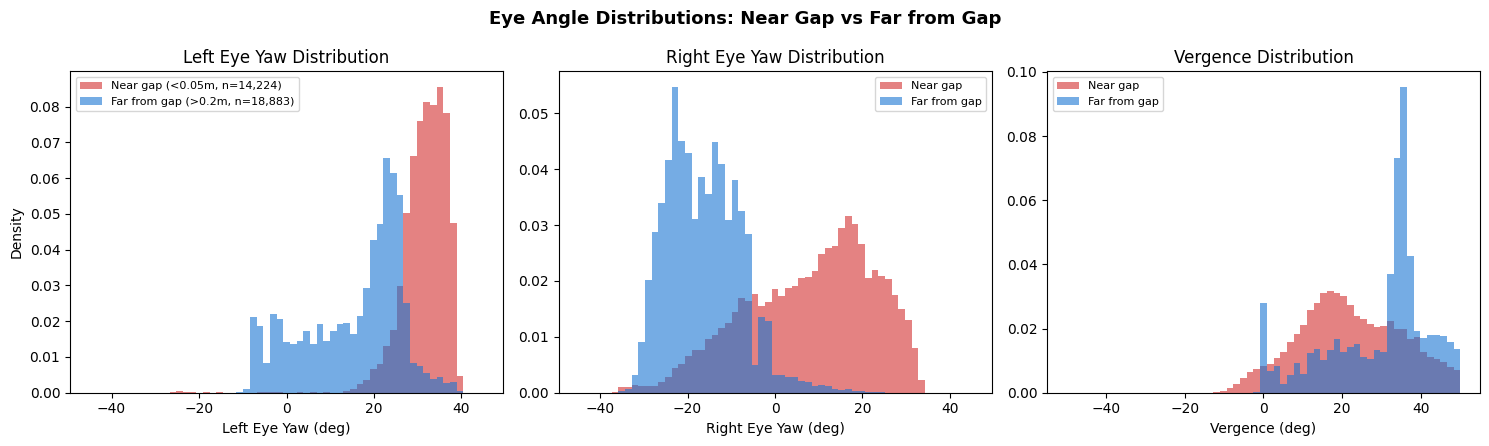

Left yaw: KS stat=0.7787, p=0.00e+00
Right yaw: KS stat=0.7142, p=0.00e+00
Vergence: KS stat=0.3577, p=0.00e+00


In [23]:
# Distribution of eye angles: near-gap vs far-from-gap
near_mask = flat_gap_prox < 0.05
far_mask = flat_gap_prox > 0.2

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
bins_deg = np.linspace(-45, 45, 60)

# Left eye
ax = axes[0]
ax.hist(
    np.degrees(flat_eye_left[near_mask]),
    bins=bins_deg,
    alpha=0.6,
    color="#D32F2F",
    density=True,
    label=f"Near gap (<0.05m, n={near_mask.sum():,})",
)
ax.hist(
    np.degrees(flat_eye_left[far_mask]),
    bins=bins_deg,
    alpha=0.6,
    color="#1976D2",
    density=True,
    label=f"Far from gap (>0.2m, n={far_mask.sum():,})",
)
ax.set_xlabel("Left Eye Yaw (deg)")
ax.set_ylabel("Density")
ax.set_title("Left Eye Yaw Distribution")
ax.legend(fontsize=8)

# Right eye
ax = axes[1]
ax.hist(
    np.degrees(flat_eye_right[near_mask]),
    bins=bins_deg,
    alpha=0.6,
    color="#D32F2F",
    density=True,
    label="Near gap",
)
ax.hist(
    np.degrees(flat_eye_right[far_mask]),
    bins=bins_deg,
    alpha=0.6,
    color="#1976D2",
    density=True,
    label="Far from gap",
)
ax.set_xlabel("Right Eye Yaw (deg)")
ax.set_title("Right Eye Yaw Distribution")
ax.legend(fontsize=8)

# Vergence
ax = axes[2]
vg_bins = np.linspace(-50, 50, 60)
ax.hist(
    np.degrees(flat_vergence[near_mask]),
    bins=vg_bins,
    alpha=0.6,
    color="#D32F2F",
    density=True,
    label="Near gap",
)
ax.hist(
    np.degrees(flat_vergence[far_mask]),
    bins=vg_bins,
    alpha=0.6,
    color="#1976D2",
    density=True,
    label="Far from gap",
)
ax.set_xlabel("Vergence (deg)")
ax.set_title("Vergence Distribution")
ax.legend(fontsize=8)

fig.suptitle(
    "Eye Angle Distributions: Near Gap vs Far from Gap", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

# KS tests
for name, near_vals, far_vals in [
    ("Left yaw", flat_eye_left[near_mask], flat_eye_left[far_mask]),
    ("Right yaw", flat_eye_right[near_mask], flat_eye_right[far_mask]),
    ("Vergence", flat_vergence[near_mask], flat_vergence[far_mask]),
]:
    ks_stat, ks_p = stats.ks_2samp(near_vals, far_vals)
    print(f"{name}: KS stat={ks_stat:.4f}, p={ks_p:.2e}")

## Population Summary: Eye Angle and Speed Over Time

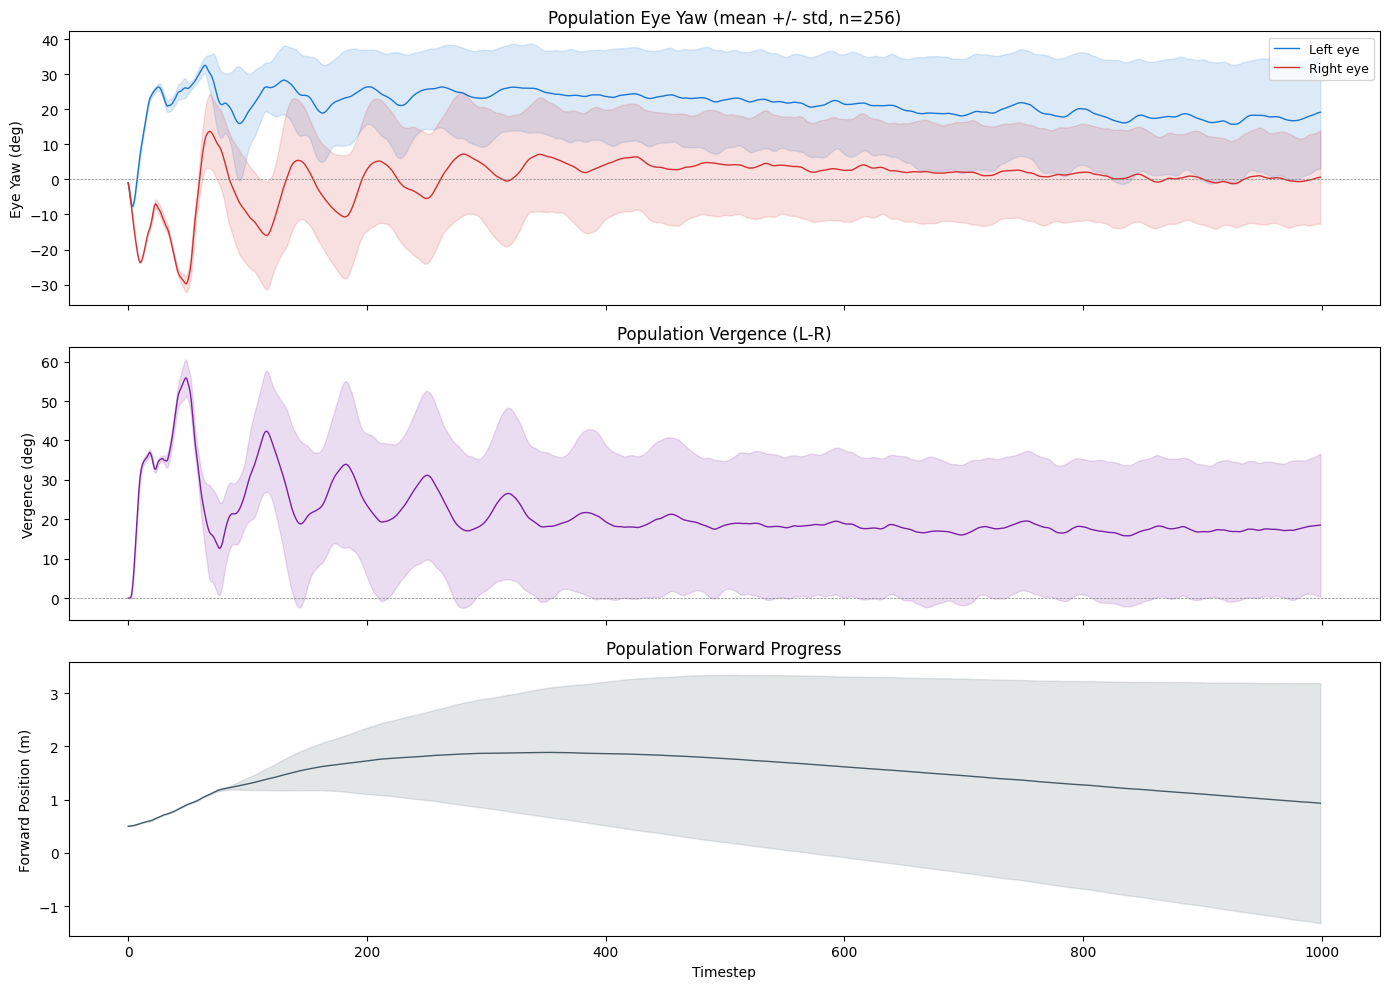

In [24]:
# Population average time series
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
t = np.arange(EPISODE_LENGTH)

# Eye yaw (mean +/- std across envs)
ax = axes[0]
for data, color, label in [
    (eye_left_yaw, "#1976D2", "Left eye"),
    (eye_right_yaw, "#D32F2F", "Right eye"),
]:
    mean = np.degrees(np.mean(data, axis=1))
    std = np.degrees(np.std(data, axis=1))
    ax.plot(t, mean, color=color, lw=1, label=label)
    ax.fill_between(t, mean - std, mean + std, color=color, alpha=0.15)
ax.set_ylabel("Eye Yaw (deg)")
ax.set_title(f"Population Eye Yaw (mean +/- std, n={N_ENVS})")
ax.legend(fontsize=9)
ax.axhline(0, color="gray", ls="--", lw=0.5)

# Vergence
ax = axes[1]
mean_vg = np.degrees(np.mean(vergence, axis=1))
std_vg = np.degrees(np.std(vergence, axis=1))
ax.plot(t, mean_vg, color="#7B1FA2", lw=1)
ax.fill_between(t, mean_vg - std_vg, mean_vg + std_vg, color="#7B1FA2", alpha=0.15)
ax.set_ylabel("Vergence (deg)")
ax.set_title("Population Vergence (L-R)")
ax.axhline(0, color="gray", ls="--", lw=0.5)

# Forward position
ax = axes[2]
mean_x = np.mean(torso_x, axis=1)
std_x = np.std(torso_x, axis=1)
ax.plot(t, mean_x, color="#455A64", lw=1)
ax.fill_between(t, mean_x - std_x, mean_x + std_x, color="#455A64", alpha=0.15)
ax.set_ylabel("Forward Position (m)")
ax.set_xlabel("Timestep")
ax.set_title("Population Forward Progress")

plt.tight_layout()
plt.show()